# Eksperimen Bonus 2: Adam Optimizer

Membandingkan **kecepatan konvergensi** antara **Gradient Descent (SGD) standar** dengan **Adam** optimizer.

Aspek yang dibandingkan:
1. Hasil akhir prediksi (akurasi)
2. Grafik training loss dan validation loss per epoch (kecepatan konvergensi)
3. Distribusi bobot dan gradien bobot

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import sys, os

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
import ffnn
# importlib.reload(ffnn)

%matplotlib inline

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Data Loading & Preprocessing

In [15]:
# Load dataset
df = pd.read_csv("../data/dataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['placement_status'].value_counts()}")
df.head()

Dataset shape: (10000, 12)
Target distribution:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [16]:
# Encode categorical features
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'placement_status' in categorical_cols:
    categorical_cols.remove('placement_status')

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target
target_le = LabelEncoder()
df['placement_status'] = target_le.fit_transform(df['placement_status'])

# Separate features and target
X = df.drop('placement_status', axis=1).values
y = df['placement_status'].values

num_classes = len(np.unique(y))
num_features = X.shape[1]
print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {target_le.classes_}")

# Split into train, validation, test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Number of features: 11
Number of classes: 2
Classes: ['Not Placed' 'Placed']

Train: 7000 samples
Val:   1500 samples
Test:  1500 samples


In [17]:
# Hyperparameters
EPOCHS = 50
LR = 0.01
BATCH_SIZE = 32
LAMBDA = 0.001
SEED = 42

print(f"Epochs: {EPOCHS}, LR: {LR}, Batch Size: {BATCH_SIZE}, Lambda: {LAMBDA}")

Epochs: 50, LR: 0.01, Batch Size: 32, Lambda: 0.001


## 2. Definisi Model untuk Eksperimen Adam

In [18]:
def create_model_base(num_features, num_classes, seed=42):
    """Model standar (sama untuk kedua eksperimen SGD vs Adam)"""
    np.random.seed(seed)
    model = ffnn.Model(
        layers=[
            ffnn.Linear(num_features, 64),
            ffnn.Relu(),
            ffnn.Linear(64, 32),
            ffnn.Relu(),
            ffnn.Linear(32, num_classes),
            ffnn.Softmax(),
        ],
        loss=ffnn.CrossEntropyLoss(),
    )
    return model


print("Arsitektur: Linear(in, 64) -> ReLU -> Linear(64, 32) -> ReLU -> Linear(32, out) -> Softmax")
print(f"Epochs: {EPOCHS}, LR: {LR}, Batch Size: {BATCH_SIZE}, Lambda: {LAMBDA}")

Arsitektur: Linear(in, 64) -> ReLU -> Linear(64, 32) -> ReLU -> Linear(32, out) -> Softmax
Epochs: 50, LR: 0.01, Batch Size: 32, Lambda: 0.001


## 3. Menjalankan Eksperimen Adam

### 3.1 Gradient Descent Standar (tanpa optimizer)

In [19]:
model_sgd = create_model_base(num_features, num_classes, seed=SEED)
history_sgd = model_sgd.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    penalty="l2", lambda_=LAMBDA,
    optimizer=None,   # SGD/Gradient Descent standar
    verbose=1, seed=SEED,
    validation_data=(X_val, y_val)
)

Epoch 1/50 [==============================] - train_loss: 0.686107 - val_loss: 0.686059
Epoch 2/50 [==============================] - train_loss: 0.647645 - val_loss: 0.648952
Epoch 3/50 [==============================] - train_loss: 0.621978 - val_loss: 0.624127
Epoch 4/50 [==============================] - train_loss: 0.604790 - val_loss: 0.607826
Epoch 5/50 [==============================] - train_loss: 0.593696 - val_loss: 0.598054
Epoch 6/50 [==============================] - train_loss: 0.586595 - val_loss: 0.592056
Epoch 7/50 [==============================] - train_loss: 0.581667 - val_loss: 0.588214
Epoch 8/50 [==============================] - train_loss: 0.578067 - val_loss: 0.585592
Epoch 9/50 [==============================] - train_loss: 0.575421 - val_loss: 0.583832
Epoch 10/50 [==============================] - train_loss: 0.573214 - val_loss: 0.582283
Epoch 11/50 [==============================] - train_loss: 0.571399 - val_loss: 0.581120
Epoch 12/50 [=================

### 3.2 Adam Optimizer

In [20]:
model_adam = create_model_base(num_features, num_classes, seed=SEED)
adam_optimizer = ffnn.Adam(lr=LR, beta1=0.9, beta2=0.999, epsilon=1e-8)

history_adam = model_adam.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    penalty="l2", lambda_=LAMBDA,
    optimizer=adam_optimizer, # Adam optimizer
    verbose=1, seed=SEED,
    validation_data=(X_val, y_val)
)

Epoch 1/50 [==============================] - train_loss: 0.525479 - val_loss: 0.541593
Epoch 2/50 [==============================] - train_loss: 0.514739 - val_loss: 0.523904
Epoch 3/50 [==============================] - train_loss: 0.520882 - val_loss: 0.532907
Epoch 4/50 [==============================] - train_loss: 0.514901 - val_loss: 0.522473
Epoch 5/50 [==============================] - train_loss: 0.510498 - val_loss: 0.523795
Epoch 6/50 [==============================] - train_loss: 0.506851 - val_loss: 0.519638
Epoch 7/50 [==============================] - train_loss: 0.505838 - val_loss: 0.519437
Epoch 8/50 [==============================] - train_loss: 0.501459 - val_loss: 0.512737
Epoch 9/50 [==============================] - train_loss: 0.506084 - val_loss: 0.518744
Epoch 10/50 [==============================] - train_loss: 0.504209 - val_loss: 0.519026
Epoch 11/50 [==============================] - train_loss: 0.517426 - val_loss: 0.527594
Epoch 12/50 [=================

## 4. Perbandingan Hasil Prediksi (SGD vs Adam)

In [21]:
from sklearn.metrics import f1_score


preds_sgd = model_sgd.predict(X_test)
preds_adam = model_adam.predict(X_test)

acc_sgd = accuracy_score(y_test, preds_sgd)
acc_adam = accuracy_score(y_test, preds_adam)

f1_sgd = f1_score(y_test, preds_sgd)
f1_adam = f1_score(y_test, preds_adam)

print("Perbandingan Hasiil prediksi: SGD vs Adam")
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10}")
print(f"{'SGD':<23} {acc_sgd:>10.4f} {f1_sgd:>10.4f}")
print(f"{'Adam':<23} {acc_adam:>10.4f} {f1_adam:>10.4f}")
print(f"{'Selisih':<23} {acc_adam - acc_sgd:>+10.4f} {f1_adam - f1_sgd:>+10.4f}")

Perbandingan Hasiil prediksi: SGD vs Adam
Model                       Accuracy   F1 Score
SGD                         0.7640     0.8156
Adam                        0.7600     0.8218
Selisih                    -0.0040    +0.0062


In [22]:
for name, preds in [("SGD", preds_sgd), ("Adam", preds_adam)]:
    print(f"Classification Report - {name}")
    print(classification_report(y_test, preds, target_names=target_le.classes_))

Classification Report - SGD
              precision    recall  f1-score   support

  Not Placed       0.72      0.63      0.67       577
      Placed       0.79      0.85      0.82       923

    accuracy                           0.76      1500
   macro avg       0.75      0.74      0.74      1500
weighted avg       0.76      0.76      0.76      1500

Classification Report - Adam
              precision    recall  f1-score   support

  Not Placed       0.77      0.54      0.63       577
      Placed       0.76      0.90      0.82       923

    accuracy                           0.76      1500
   macro avg       0.76      0.72      0.73      1500
weighted avg       0.76      0.76      0.75      1500



In [23]:
print("\nSample Predictions (first 20 test samples):")
print(f"{'Actual':<10} {'SGD':<10} {'Adam':<10}")
print("-" * 30)
for i in range(min(20, len(y_test))):
    print(f"{y_test[i]:<10} {preds_sgd[i]:<10} {preds_adam[i]:<10}")


Sample Predictions (first 20 test samples):
Actual     SGD        Adam      
------------------------------
1          1          1         
1          1          1         
1          1          1         
1          1          1         
1          0          1         
1          1          1         
1          1          1         
1          1          1         
1          1          1         
0          1          1         
1          1          1         
0          0          0         
1          1          1         
1          1          1         
1          1          1         
0          1          1         
1          0          1         
1          0          1         
1          1          1         
0          0          1         


## 5. Grafik Perbandingan Konvergensi (SGD vs Adam)

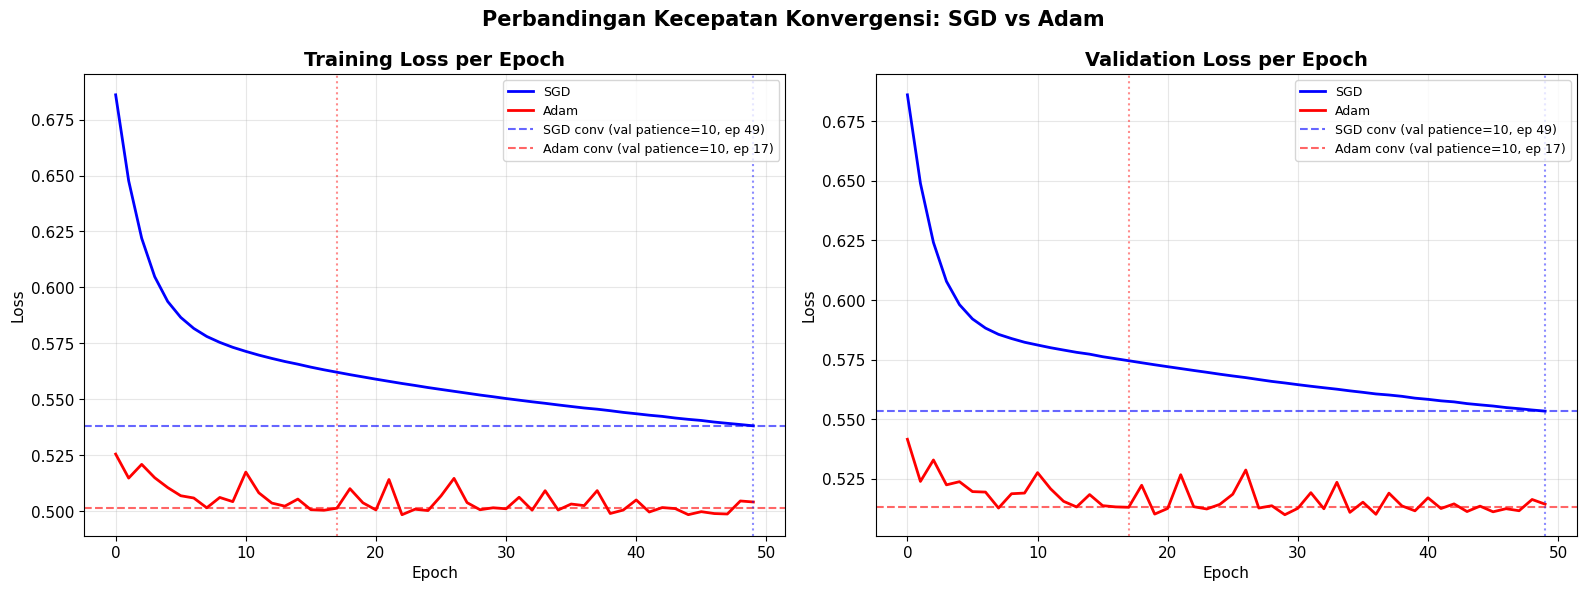

Konvergen jika validation loss tidak membaik selama 10 epoch berturut-turut.
Epoch konvergen dihitung dari validation loss, lalu dipakai sama untuk plot train dan val.
Model  Epoch Konvergen  Rule terpenuhi  Best Val Epoch  Best Val Loss  Epoch sejak best  Train loss @conv  Val loss @conv
  SGD               49           False              49       0.553388                 0          0.538108        0.553388
 Adam               17            True               7       0.512737                10          0.501269        0.513061


In [24]:
def get_convergence(val_losses, patience=10, min_delta=1e-6):
    val_losses = np.asarray(val_losses, dtype=float)

    best_loss = float("inf")
    best_epoch = 0
    wait = 0
    converged = False
    conv_epoch = len(val_losses) - 1

    for ep, loss in enumerate(val_losses):
        if loss < best_loss - min_delta:
            best_loss = float(loss)
            best_epoch = ep
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            conv_epoch = ep
            converged = True
            break

    return conv_epoch, {
        "best_val_loss": float(best_loss),
        "best_epoch": int(best_epoch),
        "patience": int(patience),
        "wait_at_end": int(wait),
        "converged_by_rule": bool(converged),
        "epochs_since_best": int(conv_epoch - best_epoch),
    }


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
summary_rows = []

sgd_train = np.asarray(history_sgd["train_loss"], dtype=float)
adam_train = np.asarray(history_adam["train_loss"], dtype=float)
sgd_val = np.asarray(history_sgd["val_loss"], dtype=float)
adam_val = np.asarray(history_adam["val_loss"], dtype=float)

sgd_conv_ep, sgd_meta = get_convergence(sgd_val, patience=10)
adam_conv_ep, adam_meta = get_convergence(adam_val, patience=10)

sgd_conv_ep = min(sgd_conv_ep, len(sgd_train) - 1, len(sgd_val) - 1)
adam_conv_ep = min(adam_conv_ep, len(adam_train) - 1, len(adam_val) - 1)

sgd_train_lvl = float(sgd_train[sgd_conv_ep])
adam_train_lvl = float(adam_train[adam_conv_ep])
sgd_val_lvl = float(sgd_val[sgd_conv_ep])
adam_val_lvl = float(adam_val[adam_conv_ep])

ax = axes[0]
ax.plot(sgd_train, label="SGD", linewidth=2, color="blue")
ax.plot(adam_train, label="Adam", linewidth=2, color="red")

ax.axhline(sgd_train_lvl, color="blue", linestyle="--", alpha=0.6, label=f"SGD conv (val patience=10, ep {sgd_conv_ep})")
ax.axhline(adam_train_lvl, color="red", linestyle="--", alpha=0.6, label=f"Adam conv (val patience=10, ep {adam_conv_ep})")
ax.axvline(sgd_conv_ep, color="blue", linestyle=":", alpha=0.45)
ax.axvline(adam_conv_ep, color="red", linestyle=":", alpha=0.45)

ax.set_title("Training Loss per Epoch", fontsize=14, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Validation Loss plot
ax = axes[1]
ax.plot(sgd_val, label="SGD", linewidth=2, color="blue")
ax.plot(adam_val, label="Adam", linewidth=2, color="red")

ax.axhline(sgd_val_lvl, color="blue", linestyle="--", alpha=0.6, label=f"SGD conv (val patience=10, ep {sgd_conv_ep})")
ax.axhline(adam_val_lvl, color="red", linestyle="--", alpha=0.6, label=f"Adam conv (val patience=10, ep {adam_conv_ep})")
ax.axvline(sgd_conv_ep, color="blue", linestyle=":", alpha=0.45)
ax.axvline(adam_conv_ep, color="red", linestyle=":", alpha=0.45)

ax.set_title("Validation Loss per Epoch", fontsize=14, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

summary_rows.extend([
    {
        "Model": "SGD",
        "Epoch Konvergen": sgd_conv_ep,
        "Rule terpenuhi": sgd_meta["converged_by_rule"],
        "Best Val Epoch": sgd_meta["best_epoch"],
        "Best Val Loss": round(sgd_meta["best_val_loss"], 6),
        "Epoch sejak best": sgd_meta["epochs_since_best"],
        "Train loss @conv": round(sgd_train_lvl, 6),
        "Val loss @conv": round(sgd_val_lvl, 6),
    },
    {
        "Model": "Adam",
        "Epoch Konvergen": adam_conv_ep,
        "Rule terpenuhi": adam_meta["converged_by_rule"],
        "Best Val Epoch": adam_meta["best_epoch"],
        "Best Val Loss": round(adam_meta["best_val_loss"], 6),
        "Epoch sejak best": adam_meta["epochs_since_best"],
        "Train loss @conv": round(adam_train_lvl, 6),
        "Val loss @conv": round(adam_val_lvl, 6),
    },
])

fig.suptitle("Perbandingan Kecepatan Konvergensi: SGD vs Adam", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("Konvergen jika validation loss tidak membaik selama 10 epoch berturut-turut.")
print("Epoch konvergen dihitung dari validation loss, lalu dipakai sama untuk plot train dan val.")
print(pd.DataFrame(summary_rows).to_string(index=False))

## 6. Distribusi Bobot & Gradien (SGD vs Adam)

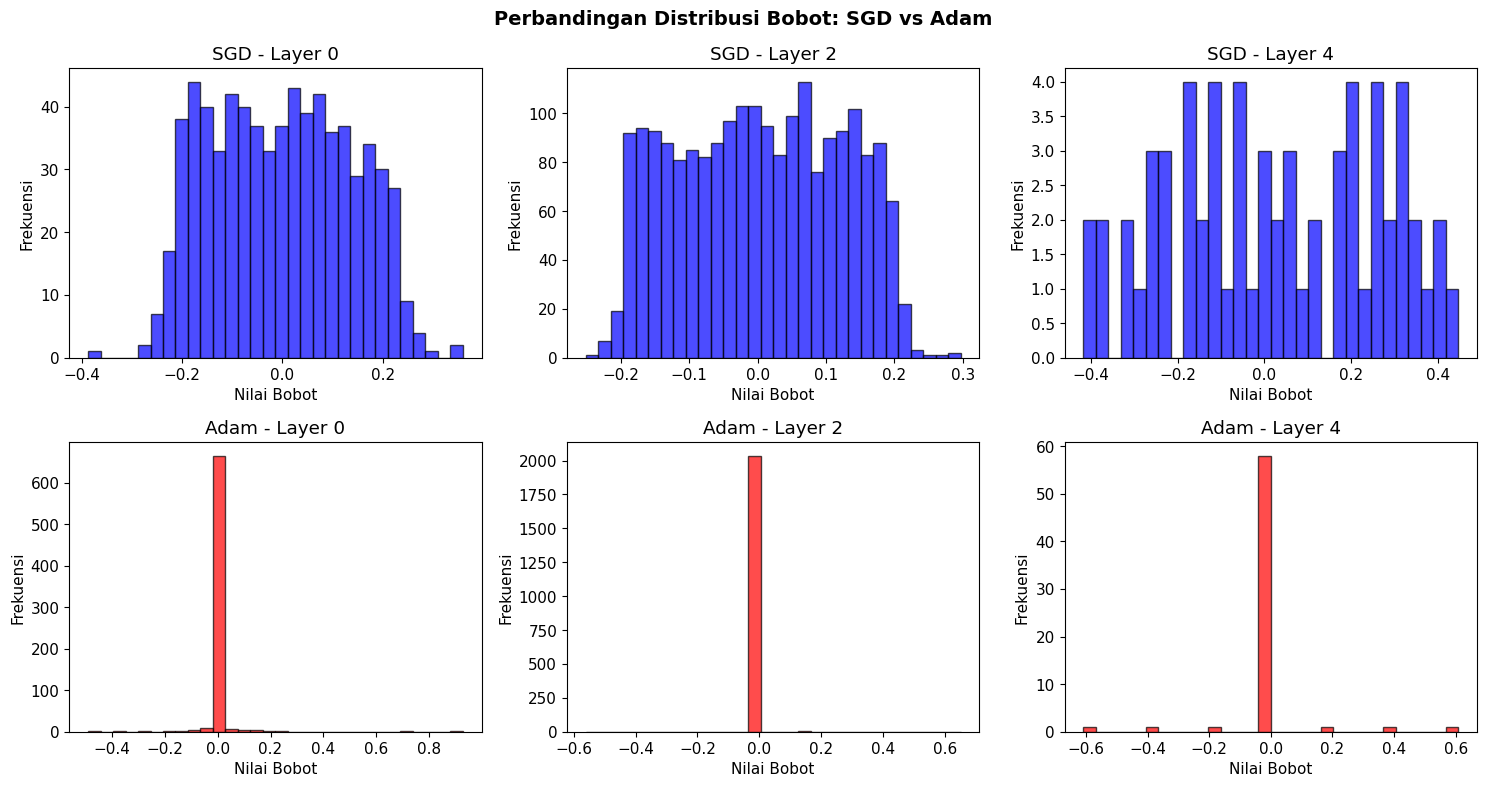

In [25]:
linear_indices = [0, 2, 4]  # indeks layer Linear di kedua model

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# SGD — bobot
for i, idx in enumerate(linear_indices):
    w = model_sgd.layers[idx].weights.data.flatten()
    axes[0][i].hist(w, bins=30, edgecolor="black", alpha=0.7, color="blue")
    axes[0][i].set_title(f"SGD - Layer {idx}")
    axes[0][i].set_xlabel("Nilai Bobot")
    axes[0][i].set_ylabel("Frekuensi")

# Adam — bobot
for i, idx in enumerate(linear_indices):
    w = model_adam.layers[idx].weights.data.flatten()
    axes[1][i].hist(w, bins=30, edgecolor="black", alpha=0.7, color="red")
    axes[1][i].set_title(f"Adam - Layer {idx}")
    axes[1][i].set_xlabel("Nilai Bobot")
    axes[1][i].set_ylabel("Frekuensi")

fig.suptitle("Perbandingan Distribusi Bobot: SGD vs Adam", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

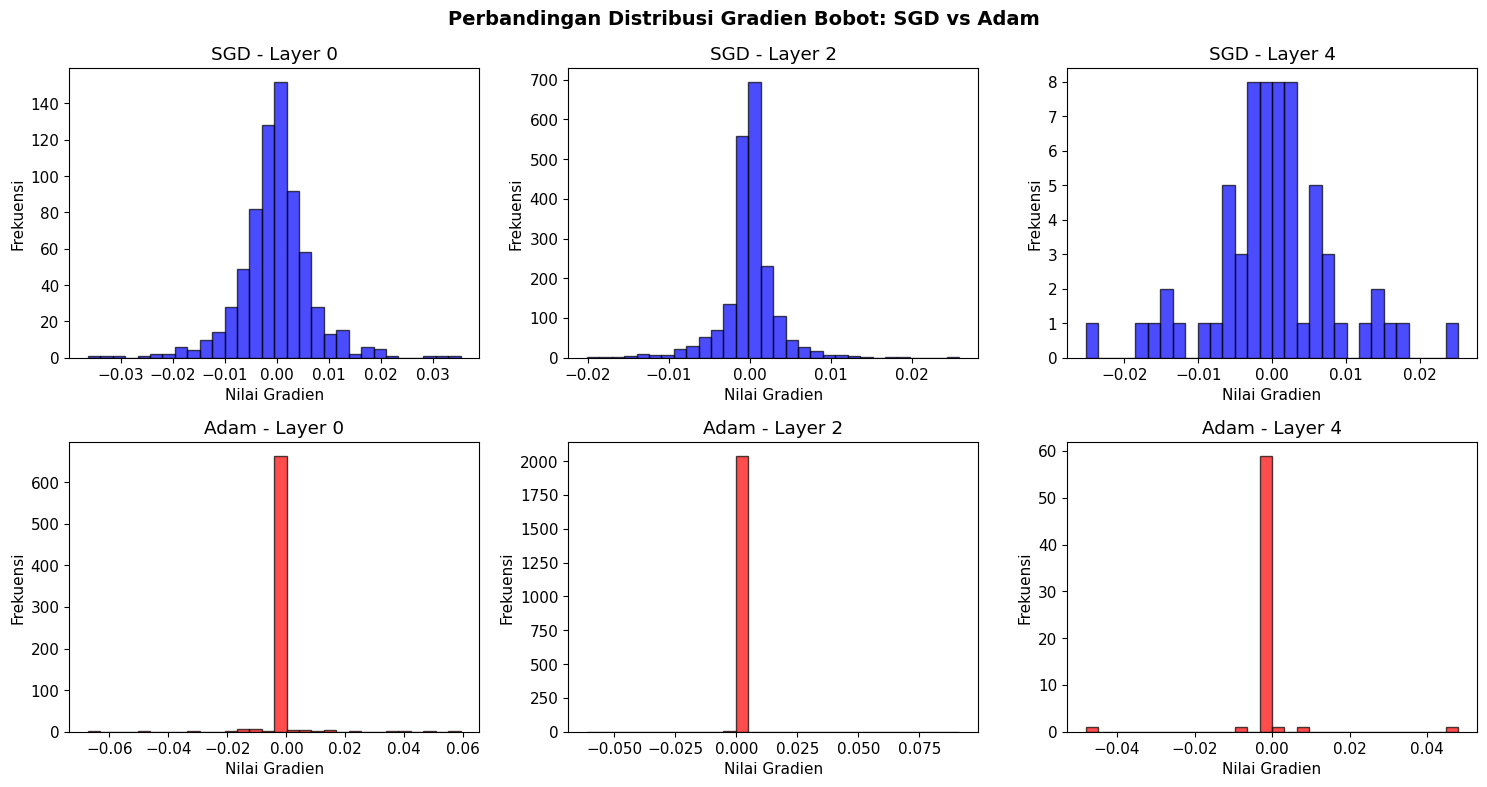

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# SGD — gradien
for i, idx in enumerate(linear_indices):
    layer = model_sgd.layers[idx]
    if hasattr(layer, 'dw') and layer.dw is not None:
        g = layer.dw.flatten()
        axes[0][i].hist(g, bins=30, edgecolor="black", alpha=0.7, color="blue")
    axes[0][i].set_title(f"SGD - Layer {idx}")
    axes[0][i].set_xlabel("Nilai Gradien")
    axes[0][i].set_ylabel("Frekuensi")

# Adam — gradien
for i, idx in enumerate(linear_indices):
    layer = model_adam.layers[idx]
    if hasattr(layer, 'dw') and layer.dw is not None:
        g = layer.dw.flatten()
        axes[1][i].hist(g, bins=30, edgecolor="black", alpha=0.7, color="red")
    axes[1][i].set_title(f"Adam - Layer {idx}")
    axes[1][i].set_xlabel("Nilai Gradien")
    axes[1][i].set_ylabel("Frekuensi")

fig.suptitle("Perbandingan Distribusi Gradien Bobot: SGD vs Adam", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Analisis Adam Optimizer

### Aspek-aspek perbandingan:

| Aspek | SGD | Adam |
|---|---|---|
| **Kecepatan konvergensi** | Lambat, loss turun gradual | Cepat, loss turun drastis di awal |
| **Stabilitas** | Bisa osilasi jika lr terlalu besar | Lebih stabil karena adaptive lr |
| **Akurasi akhir** | Bisa setara jika lr dan epoch cukup | Biasanya lebih cepat mencapai akurasi tinggi |
| **Distribusi bobot** | Bisa lebih spread, tergantung lr | Cenderung adaptif, distribusi lebih terkonsentrasi |
| **Distribusi gradien** | Magnitude gradien relatif seragam | Gradien yang sering berubah arah akan di-dampen |

### Mengapa Adam biasanya konvergen lebih cepat?

1. **Per-parameter learning rate**, parameter yang jarang di-update (gradien kecil) mendapat step lebih besar, dan sebaliknya
2. **Momentum**, membantu "melewati" saddle point dan local minima dangkal
3. **Bias correction**, di awal training, estimasi momen masih mendekati 0 (karena inisialisasi), bias correction mencegah langkah pertama yang terlalu kecil

### Kapan SGD bisa lebih baik?
- SGD dengan momentum dan learning rate schedule yang diatur dengan baik kadang menghasilkan generalisasi yang lebih baik pada beberapa kasus
- Adam bisa overfit lebih mudah karena konvergensi yang cepat